In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

from ISLP import load_data

In [20]:
Auto = load_data("Auto")

Auto.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
name,,,,,,,,
chevrolet chevelle malibu,18.0,8,307.0,130,3504,12.0,70,1
buick skylark 320,15.0,8,350.0,165,3693,11.5,70,1
plymouth satellite,18.0,8,318.0,150,3436,11.0,70,1
amc rebel sst,16.0,8,304.0,150,3433,12.0,70,1
ford torino,17.0,8,302.0,140,3449,10.5,70,1


In [21]:
X = Auto['horsepower']
y = Auto['mpg']


X = sm.add_constant(X)


In [22]:
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.606
Model:                            OLS   Adj. R-squared:                  0.605
Method:                 Least Squares   F-statistic:                     599.7
Date:                Tue, 31 Mar 2026   Prob (F-statistic):           7.03e-81
Time:                        20:29:43   Log-Likelihood:                -1178.7
No. Observations:                 392   AIC:                             2361.
Df Residuals:                     390   BIC:                             2369.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         39.9359      0.717     55.660      0.0

In [23]:
new_data = pd.DataFrame({'const': [1], 'horsepower': [98]})

prediction = model.get_prediction(new_data)
prediction.summary_frame(alpha=0.05)

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,24.467077,0.251262,23.973079,24.961075,14.809396,34.124758


/tmp/ipykernel_36061/868531379.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_vals = model.params[0] + model.params[1] * x_vals


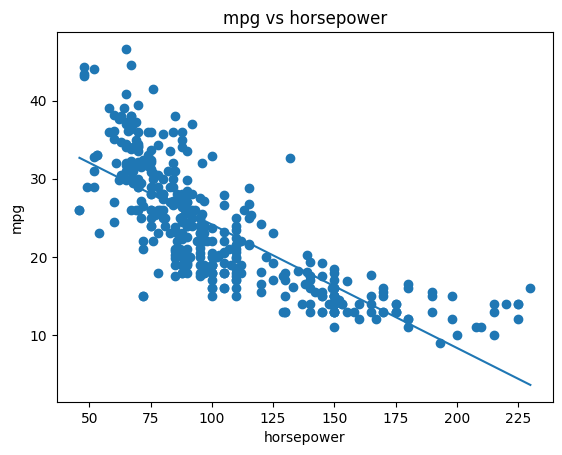

In [24]:
plt.scatter(Auto['horsepower'], Auto['mpg'])

# линия регрессии
x_vals = np.linspace(Auto['horsepower'].min(), Auto['horsepower'].max(), 100)
y_vals = model.params[0] + model.params[1] * x_vals

plt.plot(x_vals, y_vals)

plt.xlabel("horsepower")
plt.ylabel("mpg")
plt.title("mpg vs horsepower")

plt.show()

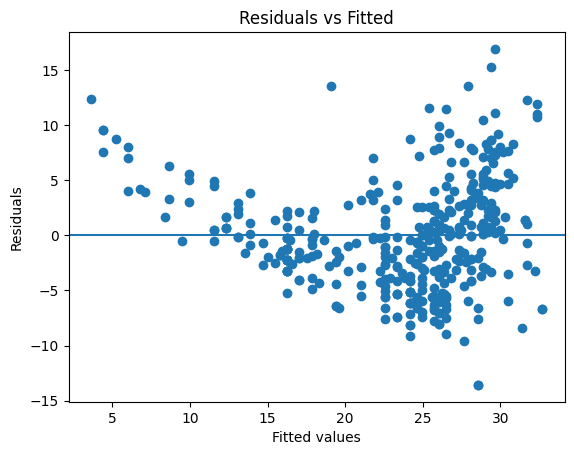

In [25]:
residuals = model.resid

plt.scatter(model.fittedvalues, residuals)
plt.axhline(0)

plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")

plt.show()

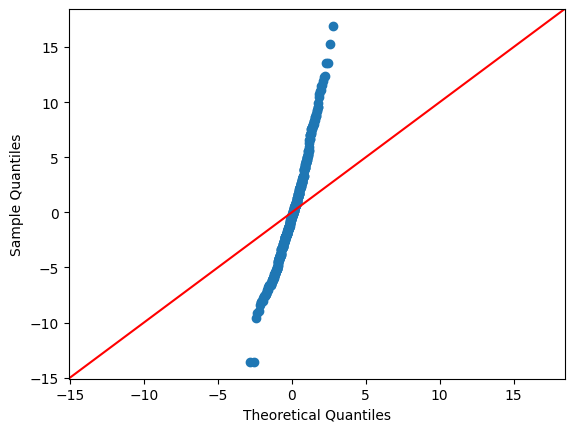

In [26]:
sm.qqplot(residuals, line='45')
plt.show()